# Time Series - Bebek İsmi Popülerliği Tahmini

Bu projede bir ismin önümüzdeki yıllarda kaç kez verileceğini tahmin edeceğiz.

Veri seti: Baby Names from Social Security Card Applications - National Data (SSA, catalog.data.gov). Zip dosyasını açıp içindeki `yob1880.txt ... yobXXXX.txt` dosyalarını `names` klasörüne koyun (`names/yob1990.txt` gibi).

Yöntem: Her ismin son 5 yılını kendi ortalamasına bölüp (oran) tüm isimler için tek bir model eğitiyoruz.

In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns',100)

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import glob, os

dosyalar = sorted(glob.glob('yob*.txt'))
len(dosyalar)

146

In [6]:
parcalar=[]
for d in dosyalar:
    t=pd.read_csv(d,names=['name','sex','count'])
    t['year']=int(os.path.basename(d)[3:7])
    parcalar.append(t)
df=pd.concat(parcalar)

In [7]:
df.head()

,name,sex,count,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880


In [8]:
df=df[df['year']>=1980]
pivot=df.groupby(['name','year'])['count'].sum().unstack(fill_value=0)
en_populer=pivot.sum(axis=1).sort_values(ascending=False).head(1000).index
pivot=pivot.loc[en_populer]

In [9]:
pivot.shape

(1000, 46)

In [10]:
pivot.head()

year,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Michael,69229,69237,68792,68581,68243,65465,64825,64208,64651,65778,65598,61077,54668,49794,44669,41576,38530,37704,36746,34038,32159,29785,28353,27223,25618,23889,22717,22079,20707,19009,17424,16859,16238,15583,15540,14540,14179,12760,11776,10652,9857,9177,8914,8450,8245,8107
Christopher,49391,50513,59653,59742,60411,60024,57102,54871,53368,53428,52550,47269,42598,38349,34910,32783,30978,29167,27061,25669,24986,23172,21718,20795,19733,19221,19727,20055,18005,16391,14310,13045,11940,10893,10406,9868,9119,8319,7350,7027,6227,5874,5594,5204,5082,4748
Matthew,38027,43531,46318,50526,50060,47369,47210,46800,46129,45548,44951,41749,37826,35852,33728,32945,32145,31565,31201,30455,28624,26861,25188,24049,22987,21516,20361,18779,17627,16028,14163,14206,14014,13381,12959,12800,12677,11745,10019,9292,8149,7499,7086,7240,7115,7008
Joshua,36274,39264,38245,36919,40532,42470,37849,40274,42950,44308,43403,41367,36343,33704,31451,30782,29250,28350,28146,27327,27597,26072,26044,25151,24334,23304,22367,20708,19256,17695,15480,13822,12699,11874,10945,9868,9276,8365,7446,6641,6024,5531,5203,5076,5276,4773
Daniel,30107,31198,32907,35006,36800,38853,36861,36141,34998,35195,33979,31101,29304,28828,28196,26832,25204,24030,23239,22768,22401,21074,21390,21125,21094,20286,20129,20298,19082,17604,15899,15332,14323,14355,13986,13563,13021,11772,11315,10609,9549,9174,9132,8421,8436,8093


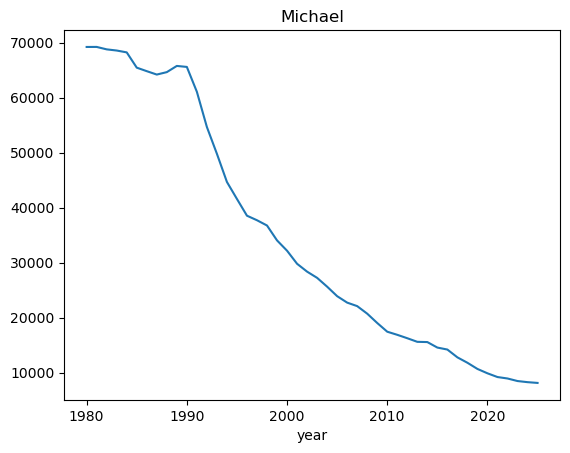

In [11]:
ornek=pivot.index[0]
pivot.loc[ornek].plot(title=ornek);

### Özellik üretimi
Her isim için 5 yıllık pencereler alıyoruz. Pencere, kendi ortalamasına bölünerek ölçekleniyor; hedef de bir sonraki yılın aynı ortalamaya oranı.

In [12]:
pencere=5
yillar=pivot.columns.tolist()
X=[];y=[];yil=[]
for isim in pivot.index:
    seri=pivot.loc[isim].values.astype(float)
    for i in range(pencere,len(seri)):
        w=seri[i-pencere:i]
        m=w.mean()
        if m==0:
            continue
        X.append(w/m)
        y.append(seri[i]/m)
        yil.append(yillar[i])
X=np.array(X);y=np.array(y);yil=np.array(yil)
X.shape

(40822, 5)

In [13]:
son_yil=yillar[-1]
test_maske=yil>son_yil-5
x_train,x_test=X[~test_maske],X[test_maske]
y_train,y_test=y[~test_maske],y[test_maske]

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [15]:
L=LinearRegression()
L.fit(x_train,y_train)
Ltahmin=L.predict(x_test)

In [16]:
r2_score(y_test,Ltahmin)

0.6032360674501174

In [17]:
np.sqrt(mean_squared_error(y_test,Ltahmin))  #RMSE

np.float64(0.12611200562472677)

In [18]:
r=RandomForestRegressor(n_estimators=100,max_depth=12,n_jobs=-1,random_state=42)
r.fit(x_train,y_train)
rtahmin=r.predict(x_test)

In [19]:
r2_score(y_test,rtahmin)

0.6997579682951196

In [20]:
np.sqrt(mean_squared_error(y_test,rtahmin)) 

np.float64(0.1097049148300927)

### Modeli kaydetme

In [ ]:
import pickle
son_model=RandomForestRegressor(n_estimators=100,max_depth=12,n_jobs=-1,random_state=42)
son_model.fit(X,y)
pickle.dump(son_model,open('isim_model.pkl','wb'))
pickle.dump(pivot,open('isim_pivot.pkl','wb'))